# Machine Learning Fundamentals: Regression

In this notebook, we will explore regression models using Python's **scikit-learn** library. Scikit-learn provides a wide range of tools for building and evaluating machine learning models, including regression algorithms.

Regression allows us to predict continuous outcomes (such as prices or measurements) based on input features.
We will start with linear regression and gradually explore non-linear models, model evaluation, overfitting, and regularization.


## 1. Load and explore the dataset

We will use scikit-learn's **diabetes** dataset, which contains ten clinical variables and measurements from n=442 diabetes patients, as well as a quantitative measure of disease progression one year after baseline. Diabetes is a chronic disease that affects how the body processes blood sugar (glucose). The dataset includes features such as age, sex, body mass index (BMI), average blood pressure, and six blood serum measurements.

The goal is to predict the disease progression of these patients based on the baseline measurements. Prediction of disease progression is a popular and practical application of regression models in healthcare, as it can help clinicians make informed decisions about patient care and treatment plans.

You can find more information about the contents of the dataset on the [documentation page](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset).

<div class="alert alert-block alert-info"> 
<b>QUESTIONS</b>

- How many observations doe we have compared to the number of features? 
- Is this a "small data" or "large data" problem?
</div>

In [ ]:
import pandas as pd
from sklearn.datasets import load_diabetes

# Load diabetes dataset
_diabetes = load_diabetes()
X = _diabetes.data      # Features
y = _diabetes.target    # Target variable (disease progression)
feature_names = _diabetes.feature_names

print(f"Features shape: {X.shape}  |  Target shape: {y.shape}")
print("Features:", feature_names)

# Put into a DataFrame for convenience
X_df = pd.DataFrame(X, columns=feature_names)
df = X_df.copy()
df["target"] = y

df.head()

Features shape: (442, 10)  |  Target shape: (442,)
Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


***

The pandas library provides a convenient way to load the diabetes dataset into a DataFrame, which allows us to easily explore and manipulate the data:

- [*describe*](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html) provides summary statistics for each feature, including count, mean, standard deviation, minimum, and maximum values.
- [*hist*](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.hist.html) visualizes the histograms of all the features in our dataset.

<div class="alert alert-block alert-info"> 
<b>QUESTIONS</b>

Many regression models assume that features are on comparable scales. In our case the measurements come from a wide range of different sources (clinical parameters, blood measurements etc.). Do you think it is necessary to apply feature scaling here?
</div>


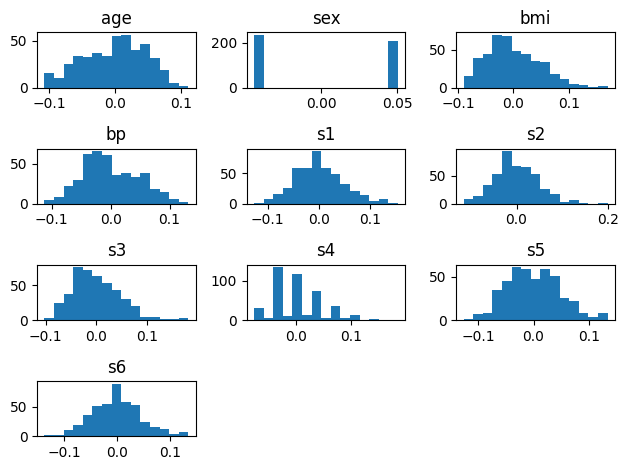

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


In [2]:
from matplotlib import pyplot as plt

# Visualize feature distributions
X_df.hist(bins=15, grid=False)
plt.tight_layout()
plt.show()

# Calculate basic statistics
X_df.describe()

***

Now that we have a good overview of the featue value distributions, the last thing to check is the target variable. Use the following code to plot the distribution of the target variable and the correlation with the features.

<div class="alert alert-block alert-info"> 
<b>QUESTIONS</b>

- Look at the histogram of the target variable. Do you think this is a good distribution for a regression problem? Are there important outliers?
- Are the features strongly correlated with the target variable? Is this a good indication to try (non-)linear regression?
</div>

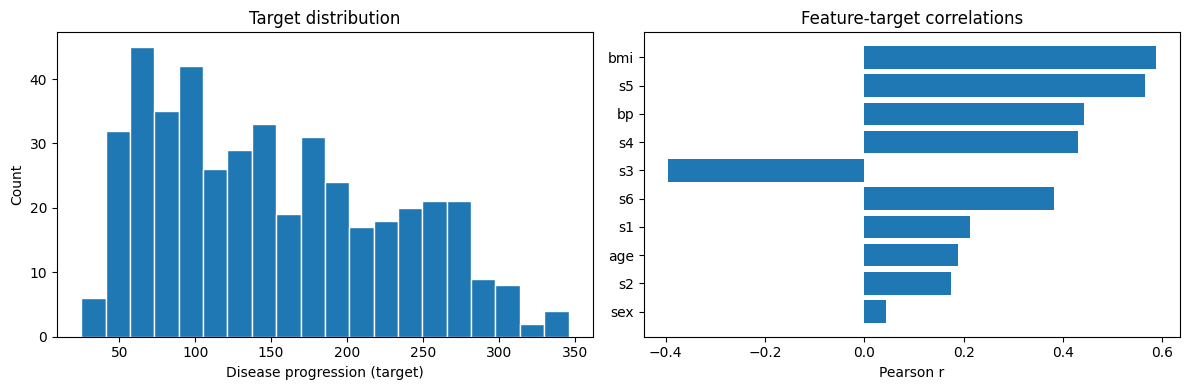

In [7]:
import numpy as np

# Plot target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y, bins=20, edgecolor="white")
axes[0].set_title("Target distribution")
axes[0].set_xlabel("Disease progression (target)")
axes[0].set_ylabel("Count")

# Plot feature-target correlations
corr = df.corr(numeric_only=True)["target"].drop("target").sort_values(key=np.abs, ascending=False)
axes[1].barh(corr.index[::-1], corr.values[::-1])
axes[1].set_title("Feature-target correlations")
axes[1].set_xlabel("Pearson r")
plt.tight_layout()
plt.show()


## 2. Baseline Linear Regression

We'll start simple by fitting a linear regression model to the dataset. Linear regression assumes a linear relationship between the input features and the target variable. The model learns coefficients for each feature that represent their contribution to the prediction.

Scikit-learn's provides a straightforward implementation of many different regression and classification models. The fitting process is the same for all models: we create an instance of the model class, and then call the *fit* method with our training data. Predicting on new data is done with the *predict* method.

> Note: Before fitting the model, we have to split our data in a training and test set (using scikit-learn's [*train_test_split*](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) function). This allows us to evaluate the performance of our model on unseen data, which is crucial for assessing its generalization ability.

<div class="alert alert-block alert-info"> 
<b>QUESTIONS</b>

- What would happen if we fit the model on the entire dataset and evaluate it on the same data? Why is this a problem?
- How would you interpret a positive vs negative coefficient?
- Can we interpret the absolute size of coefficients directly? When would this (not) be possible? (Hint: think about the scale of each feature (from the *.describe()* output))
</div>

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit baseline Linear Regression
linreg = LinearRegression()
linreg.fit(X_train, y_train)

print("Intercept:", linreg.intercept_)
coefs = pd.Series(linreg.coef_, index=feature_names).sort_values(key=np.abs, ascending=False)
print("Top coefficients by magnitude:\n", coefs.head(5))

Intercept: 151.34560453985995
Top coefficients by magnitude:
 s1    -931.488846
s5     736.198859
bmi    542.428759
s2     518.062277
bp     347.703844
dtype: float64


***

Choose one feature to plot against the target variable, and plot the regression line on top of the scatter plot. This will help you visualize the relationship between the feature and the target variable, and how well the linear regression model fits the data.

<div class="alert alert-block alert-info"> 
<b>QUESTIONS</b>

- Does the relationship look strongly linear?
- Would you feel confident using this single feature to make predictions?
- What does the spread around the regression line tell you?
</div>

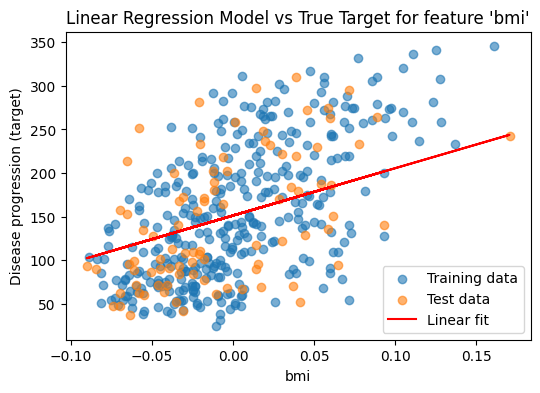

In [12]:
feature_to_plot = "bmi"  # Choose a feature to plot
feature_index = feature_names.index(feature_to_plot)

plt.figure(figsize=(6, 4))
plt.scatter(X_train[:, feature_index], y_train, alpha=0.6, label="Training data")
plt.scatter(X_test[:, feature_index], y_test, alpha=0.6, label="Test data")
plt.plot(X_test[:, feature_index], linreg.intercept_ + linreg.coef_[feature_index] * X_test[:, feature_index], color='red', label='Linear fit')
plt.xlabel(feature_to_plot)
plt.ylabel("Disease progression (target)")
plt.title(f"Linear Regression Model vs True Target for feature '{feature_to_plot}'")
plt.legend()
plt.show() 

***

Ofcourse, no model is perfect, and we need to evaluate how well our model is doing. Scikit-learn provides a range of different error metrics for regression problems, such as R2, mean absolute error (MAE), and mean squared error (MSE). Each of these metrics captures a different aspect of the model's performance, and it's important to consider multiple metrics when evaluating a regression model.

<div class="alert alert-block alert-info"> 
<b>QUESTIONS</b>

- How do you interpret the difference between the error metrics on the training and test set? Is this a reasonable difference?
- Does a single number like R2 or MAE fully describe the model quality?
</div>

In [14]:
# Helper function to compute metrics
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2}

# Evaluate on train and test
train_pred = linreg.predict(X_train)
test_pred = linreg.predict(X_test)

results_baseline = pd.DataFrame(
    [regression_metrics(y_train, train_pred), regression_metrics(y_test, test_pred)],
    index=["Train", "Test"]
)
results_baseline

,MSE,RMSE,MAE,R2
Train,2868.549703,53.558843,43.483504,0.527919
Test,2900.193628,53.853446,42.794095,0.452603


***

After having fitted and evaluated our model, we can plot the prediction errors against the actual prediction values. Plotting the prediction errors helps to identify whether there are any systematic patterns in the errors, such as whether the model is consistently underestimating or overestimating the target variable. It can also reveal whether the errors are randomly distributed or if there are certain regions of the feature space where the model performs worse.

<div class="alert alert-block alert-info"> 
<b>QUESTIONS</b>

Do you spot any patterns in the residuals?
</div>

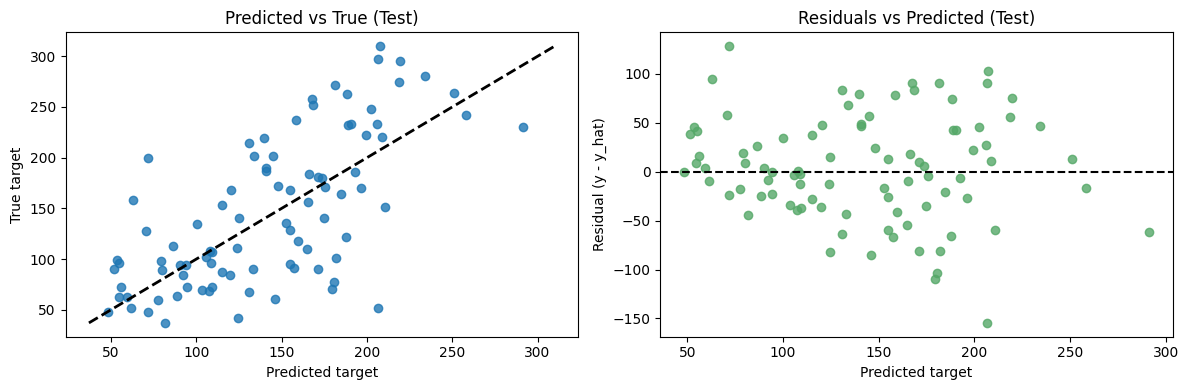

In [18]:
# Visualize predictions vs. truth and residuals (Test set)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Predicted vs True
axes[0].scatter(test_pred, y_test, alpha=0.8)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[0].set_xlabel("Predicted target")
axes[0].set_ylabel("True target")
axes[0].set_title("Predicted vs True (Test)")

# Residuals
residuals = y_test - test_pred
axes[1].scatter(test_pred, residuals, color="#55A868", alpha=0.8)
axes[1].axhline(0, color='k', linestyle='--')
axes[1].set_xlabel("Predicted target")
axes[1].set_ylabel("Residual (y - y_hat)")
axes[1].set_title("Residuals vs Predicted (Test)")

plt.tight_layout()
plt.show()


## 3. Polynomial Regression

Linear regression is a powerful tool, but it can only capture linear relationships between the features and the target variable. In many real-world problems, the relationship between the features and the target variable may be non-linear. To capture these non-linear relationships, we can use polynomial regression.

The core idea of polynomial regression is to create new features by taking the original features and applying polynomial transformations to them. For example, if we have a feature x, we can create new features like x^2, x^3, and so on. This allows us to capture more complex relationships between the features and the target variable.

Here you will write your own code to fit a polynomial regression model with degree 2 (i.e. including the original features, their squares, and their pairwise interactions). You can use scikit-learn's [*PolynomialFeatures*](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html) to easily create these polynomial features. Similar to the syntax for fitting a linear regression model, you can create an instance of the polynomial features transformer, *fit* it on the training data, and then *transform* both the training and test data to create the new polynomial features.

The entire workflow includes the following steps:
- Build polynomial features (degree=2)
- Scale the polynomial features
- Fit a linear regression model on the polynomial features

<div class="alert alert-block alert-info"> 
<b>QUESTIONS</b>

- Why do we apply fit_transform on the training data and transform on the test data?
- Can we swap the order of the polynomial transformation and scaling? (i.e. could we do scaling first?)
</div>


In [ ]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Build polynomial features (degree=2)
poly = PolynomialFeatures(degree=_)
poly = _                # Fit the polynomial transformation on the training data
X_train_poly = _        # Apply transform to the training data
X_test_poly = _         # Apply transform to the test data

# Scale the polynomial features
scaler = StandardScaler()
X_train_poly_scaled = _ # Use fit_transform to fit the scaler on the training data and transform it (in one step)
X_test_poly_scaled =  _ # Apply transform on the test data

# Fit Linear Regression on polynomial features
linreg_poly = _         # Create new model instance
_ = _                   # Fit the model


In [23]:
# Predict and evaluate
train_pred_poly = linreg_poly.predict(X_train_poly_scaled)
test_pred_poly = linreg_poly.predict(X_test_poly_scaled)

results_poly = pd.DataFrame(
    [regression_metrics(y_train, train_pred_poly), regression_metrics(y_test, test_pred_poly)],
    index=["Train (poly)", "Test (poly)"]
)

# Compare to baseline
pd.concat([results_baseline, results_poly], axis=0)

,MSE,RMSE,MAE,R2
Train,2868.549703,53.558843,43.483504,0.527919
Test,2900.193628,53.853446,42.794095,0.452603
Train (poly),2393.138618,48.919716,39.142610,0.606158
Test (poly),3096.028307,55.641965,43.581693,0.415640


***

Now we can change the degree of the polynomial transformations and investigate its effect on the performance of the regression model. As we increase the degree of the polynomial, the model becomes more flexible and can fit the training data better. However, at some point, the model will start to overfit the training data and perform worse on the test set.

<div class="alert alert-block alert-info"> 
<b>QUESTIONS</b>

- Which model degree looks most reasonable?
- At what point does the model start reacting to noise?
- How would you justify your choice *without* looking at test data? (Hint: how do you validate your model parameters without consuming your test set?)
</div>

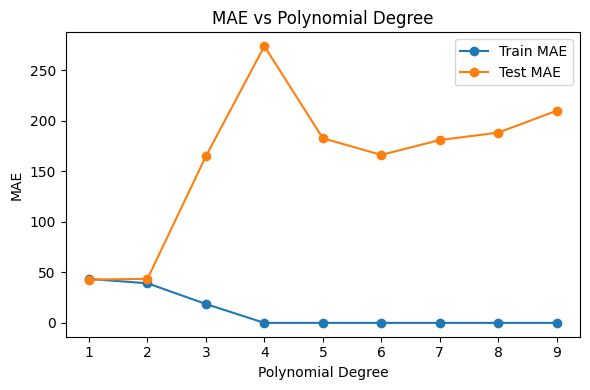

In [ ]:
# Compare different polynomial degrees
results_degree = [] 
for deg in range(1, 10):
    # INSERT YOUR OWN CODE F0R THE POLYNOMIAL REGRESSION HERE #
    # Build polynomial features

    # Scale the polynomial features

    # Fit Linear Regression on polynomial features

    # Predict and evaluate
    
    # Store results
    train_metrics = regression_metrics(y_train, train_pred_poly)
    test_metrics = regression_metrics(y_test, test_pred_poly)
    results_degree.append({
        "Degree": deg,
        "Train_MAE": train_metrics["MAE"],
        "Test_MAE": test_metrics["MAE"]
    })

# Plot the results
results_degree_df = pd.DataFrame(results_degree)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(results_degree_df["Degree"], results_degree_df["Train_MAE"], marker='o', label="Train MAE")
ax.plot(results_degree_df["Degree"], results_degree_df["Test_MAE"], marker='o', label="Test MAE")
ax.set_xlabel("Polynomial Degree")
ax.set_ylabel("MAE")
ax.set_title("MAE vs Polynomial Degree")
ax.legend()
plt.tight_layout()

## 4. Regularization to control complexity

As we saw in the example above, increasing the complexity of the model by adding polynomial features can lead to overfitting, where the model captures noise in the training data rather than the underlying pattern. To mitigate this issue, we can apply regularization techniques to control the complexity of the fitted models.

In the case of regression, we can use regularization with Ridge, Lasso or ElasticNet which shrinks coefficients and improves generalization.

Use the code below to fit a non-regularized and regularized polynomial regression model. Look at the effect of regularization on the magnitude of the model coefficients.

<div class="alert alert-block alert-info"> 
<b>QUESTIONS</b>

- How does regularization affect the coefficient values?
- Are there differences between the effect of Ridge or Lasso on the coefficient values?
- Which model (Ridge or Lasso) would you prefer if interpretability matters?
- Extra exercise: fit an ElasticNet regression model and compare the effect of regularization on the coefficient values with Ridge and Lasso.
</div>


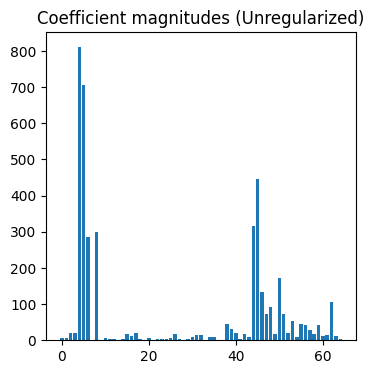

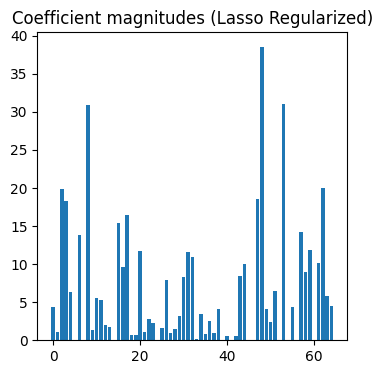

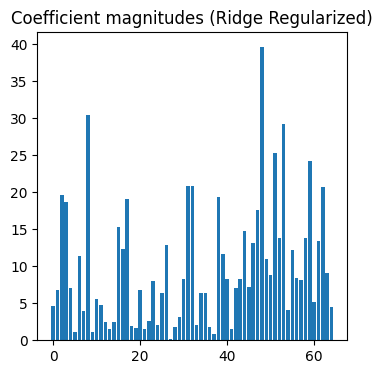

In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# Build features
poly = PolynomialFeatures(2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_train_poly = StandardScaler().fit_transform(X_train_poly)

# Fit unregularized regression
linreg_poly = LinearRegression()
linreg_poly.fit(X_train_poly, y_train)

# Fit regularized regression model (Ridge)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_poly, y_train)

# Fit regularized regression model (Lasso)
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_poly, y_train)


# INSERT CODE TO FIT ELASTICNET REGRESSION MODEL HERE #


# Plot coefficient magnitudes
fig, ax = plt.subplots(figsize=(4, 4))
coef_lin = np.abs(linreg_poly.coef_)
x = np.arange(len(coef_lin))
ax.bar(x, coef_lin, label="Unregularized")
ax.set_title("Coefficient magnitudes (Unregularized)")

fig, ax = plt.subplots(figsize=(4, 4))
coef_reg = np.abs(ridge.coef_)
x = np.arange(len(coef_reg))
ax.bar(x, coef_reg, label="Ridge Regularized")
ax.set_title("Coefficient magnitudes (Ridge Regularized)")

fig, ax = plt.subplots(figsize=(4, 4))
coef_lasso = np.abs(lasso.coef_)
x = np.arange(len(coef_lasso))
ax.bar(x, coef_lasso, label="Lasso Regularized")
ax.set_title("Coefficient magnitudes (Lasso Regularized)")

plt.show()

***

Now that we know how regularization works, we can inspect how it affects the generalization of the fitted model. To do this, we compute one of the error metrics (MAE) for each type of regularization across a range of polynomial degrees.

>Warning: this code can take a while to run depending on your hardware, which is why we limit the range of polynomial degrees between 1-5.

<div class="alert alert-block alert-info"> 
<b>QUESTIONS</b>

- Why might regularization improve test performance but worsen training performance?
- Which regularization model gives the best generalization results? Would you always choose this regularization model? Why (not)?
</div>

Processing polynomial degree: 1
Processing polynomial degree: 2
Processing polynomial degree: 3
Processing polynomial degree: 4


/Users/jolan.heyse/Library/CloudStorage/OneDrive-VIB/Documents/Course Material/2026/machine-learning-and-deep-learning-fundamentals/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.521e+02, tolerance: 2.145e+02
  model = cd_fast.enet_coordinate_descent(


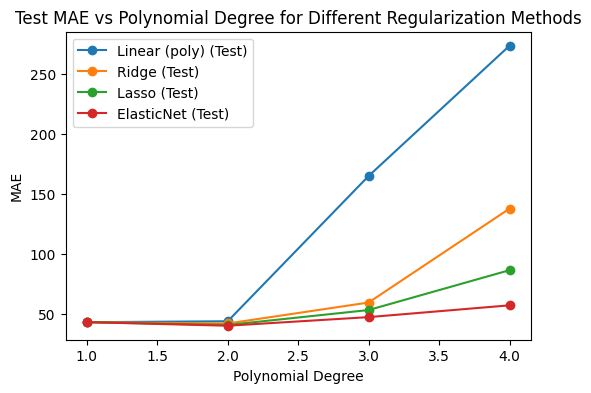

In [31]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

models = {
    "Linear (poly)": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Lasso": Lasso(alpha=0.1, max_iter=10000, random_state=42),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000, random_state=42),
}

results = []

# Loop over polynomial degrees
for deg in range(1, 5):
    print(f"Processing polynomial degree: {deg}")
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    scaler = StandardScaler()
    X_train_poly_scaled = scaler.fit_transform(X_train_poly)
    X_test_poly_scaled = scaler.transform(X_test_poly)
    
    for model_name, model in models.items():
        # Fit model
        model.fit(X_train_poly_scaled, y_train)

        # Predict
        train_pred = model.predict(X_train_poly_scaled)
        test_pred = model.predict(X_test_poly_scaled)

        # Store results
        train_metrics = regression_metrics(y_train, train_pred)
        test_metrics = regression_metrics(y_test, test_pred)
        results.append({
            "Model": model_name,
            "Degree": deg,
            "Train_MAE": train_metrics["MAE"],
            "Test_MAE": test_metrics["MAE"]
        })

# Plot the results
results_df = pd.DataFrame(results)
fig, ax = plt.subplots(figsize=(6, 4))

for model_name in models.keys():
    subset = results_df[results_df["Model"] == model_name]
    ax.plot(
        subset["Degree"],
        subset["Test_MAE"],
        marker="o",
        label=f"{model_name} (Test)"
    )

ax.set_xlabel("Polynomial Degree")
ax.set_ylabel("MAE")
ax.set_title("Test MAE vs Polynomial Degree for Different Regularization Methods")
ax.legend()
plt.show()


## 5. Wrap-up

In this notebook, we explored the progression from simple to more flexible regression models:

- **Linear regression** serves as a strong, interpretable baseline.
- **Evaluation metrics** such as MAE, RMSE, and R² allow us to compare training and test performance and diagnose overfitting.
- **Residual analysis** helps uncover systematic patterns that signal model misspecification.
- **Polynomial features** increase model flexibility, while feature standardization improves numerical stability and optimization.
- **Regularization techniques** (Ridge, Lasso, and ElasticNet) control model complexity by shrinking coefficients, often leading to better generalization.

Together, these tools form a practical workflow for building, diagnosing, and improving regression models in real-world settings.

---

## Optional exercises (for early finishers)

These sections are optional. You can run them to deepen your understanding.


### A. Collinearity checks

Highly correlated features can lead to unstable coefficient estimates and make model interpretation difficult. If both BMI and blood pressure are highly correlated, for example, it may be difficult to determine which of these features is more important for predicting disease progression. This can lead to large fluctuations in the coefficient estimates when the model is trained on different subsets of the data (the model might give a larger weight to BMI or blood pressure depending on the samples included in the training data), making it harder to interpret the model's results.

In this exercise, we will:
- Visualize the pairwise correlations between the original features using a correlation heatmap
- Compute the Variance Inflation Factor (VIF) to quantify multicollinearity

These diagnostics help identify redundancy in the feature set and inform whether feature selection or regularization may be beneficial.

<blockquote>
<b>Interpretation:</b>

- Highly correlated features can make coefficients unstable and harder to interpret. Predictions can still be good, but coefficient signs and magnitudes may fluctuate. In the heatmap, look for correlation values near ±0.7–0.8; these indicate potential redundancy.
- The Variance Inflation Factor (VIF) models the same effect by quantifying how much the variance of a coefficient is inflated due to correlations with other features. Values above 5–10 suggest problematic multicollinearity.
</blockquote>

<div class="alert alert-block alert-info"> 
<b>QUESTIONS</b>

- What can you say about the collinearity in this dataset?
- Is it important to address the collinearity if the main goal is prediction?
- Can you think of a way to reduce the collinearity in the dataset?
</div>

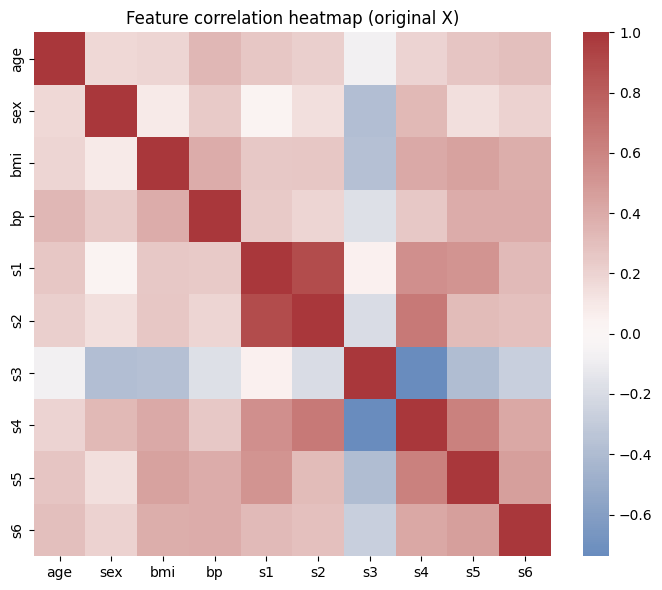

,feature,VIF
5,s1,59.202510
6,s2,39.193370
7,s3,15.402156
9,s5,10.075967
8,s4,8.890986
3,bmi,1.509437
10,s6,1.484623
4,bp,1.459428
2,sex,1.278071
1,age,1.217307


In [32]:
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Correlation heatmap (original features)
plt.figure(figsize=(7,6))
sns.heatmap(X_df.corr(numeric_only=True), annot=False, cmap="vlag", center=0)
plt.title("Feature correlation heatmap (original X)")
plt.tight_layout()
plt.show()

# VIF with statsmodels
X_const = sm.add_constant(X_df)  # add intercept for VIF computation
vif = pd.DataFrame()
vif["feature"] = X_const.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
vif = vif[vif["feature"] != "const"].sort_values("VIF", ascending=False)
display(vif)


## B. Dimensionality reduction

Highly correlated features can inflate coefficient variance and make interpretation difficult. One way to reduce this effect is to project the data into a lower-dimensional space using [Principal Component Analysis (PCA)](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html).

PCA is an unsupervised technique that can be used to reduce the dimensionality of your dataset. The PCA components are linear combinations of the original features, and are computed in such a way that all the components are orthogonal (i.e. uncorrelated) to each other.

The components are also ranked by how much of the variance of the dataset they explain. In other words, the first component contains the most variance of our dataset, the second component is orthogonal to the first and contains slightly less variance, and so on. By keeping only the first *N* components, we obtain a lower-dimensional feature space (with dimensionality *N*) with features that are linearly independent of each other and capture the most important patterns in the data.

<p align="center">
<img src="../data/PCA.png" alt="PCA example" width="400"/>
</p>

If you want to learn more about PCA, you can check [this step by step explanation](https://builtin.com/data-science/step-step-explanation-principal-component-analysis).
</blockquote>

<div class="alert alert-block alert-info"> 
<b>QUESTIONS</b>

- Look at the cumulative explained variance curve. After how many components does it platteau?
- What does this tell you about the amount of redundant features?
</div>

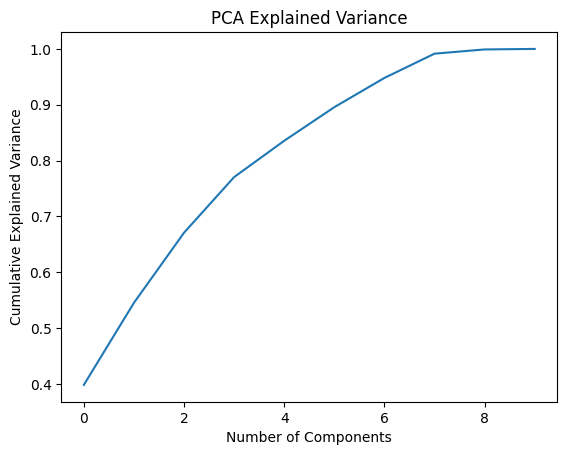

In [47]:
from sklearn.decomposition import PCA

pca = PCA()
X_train_pca = pca.fit_transform(X_train)  # Use the polynomial features from earlier
X_test_pca = pca.transform(X_test)

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

***

Now we can fit a regression model on the PCA components instead of the original features. This will give us a model with uncorrelated features, and possibly better generalization performance due to the reduced dimensionality and multicollinearity.

<div class="alert alert-block alert-info"> 
<b>QUESTIONS</b>

- How does the performance of the regression model on the PCA components compare to the performance of the regression model on the original features?
- What is the effect on the interpretability of the regression model?
</div>

In [49]:
# Fit Linear Regression on the first 5 PCA components
linreg_pca = LinearRegression()
linreg_pca.fit(X_train_pca[:, :5], y_train)

# Predict and evaluate
train_pred_pca = linreg_pca.predict(X_train_pca[:, :5])
test_pred_pca = linreg_pca.predict(X_test_pca[:, :5])

# Compare with baseline
results_pca = pd.DataFrame(
    [regression_metrics(y_train, train_pred_pca), regression_metrics(y_test, test_pred_pca)],
    index=["Train (PCA)", "Test (PCA)"]
)
pd.concat([results_baseline, results_pca], axis=0)


,MSE,RMSE,MAE,R2
Train,2868.549703,53.558843,43.483504,0.527919
Test,2900.193628,53.853446,42.794095,0.452603
Train (PCA),3012.410311,54.885429,44.643339,0.504244
Test (PCA),2864.104942,53.517333,43.277001,0.459414
